<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

In [2]:
import io
import requests
from transformers import AutoModel, AutoTokenizer, AutoConfig, PreTrainedModel
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import DataCollatorWithPadding, get_cosine_schedule_with_warmup, get_linear_schedule_with_warmup
import copy
from typing import Union, Dict, Any, Optional, List, Tuple
import numpy as np

from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

Посмотрим на данные и немного их почистим

In [3]:
response = requests.get(url="https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/export?format=xlsx")
df = pd.read_excel(io.BytesIO(response.content), index_col=0).dropna()

df.head(3)

,problem_text,topic
0,To prove that the sum of the numbers of the ex...,number_theory
1,( b) Will the statement of the previous challe...,number_theory
2,The quadratic three-member graph with the coef...,polynoms


In [4]:
df.shape

(5268, 2)

In [6]:
df = df.drop_duplicates().reset_index(drop=True)

In [7]:
df.shape

(5241, 2)

In [8]:
topics = sorted(df["topic"].unique().tolist())
print("Классы:", topics)

Классы: ['combinatorics', 'dirichlet', 'geometry', 'graphs', 'invariant', 'number_theory', 'polynoms']


In [9]:
labels2ids = {topic: number for topic, number in zip(df.topic.unique(), list(range(df.topic.nunique())))}
ids2labels = {v: k for k, v in labels2ids.items()}

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['topic'], random_state=42)

len(train_df), len(test_df)

(4192, 1049)

Создадим датасет

In [10]:
class CustomDataset(Dataset):
    def __init__(self, df, labels2ids, ids2labels, tokenizer, device=device):
        self.dataset = df.copy()
        self.n_classes = self.dataset.topic.nunique()
        self.labels2ids = labels2ids
        self.ids2labels = ids2labels
        self.tokenizer = tokenizer
        self.device = device

    def __getitem__(self, idx):
        row = self.dataset.iloc[idx]
        text = row['problem_text']
        target = self.labels2ids[row['topic']]
        encoding = self.tokenizer(text, truncation=True, max_length=512, padding='max_length', return_tensors='pt')
        return ({key: val.squeeze(0).to(self.device) for key, val in encoding.items()},
            torch.tensor(target).to(self.device))

    def __len__(self):
        return len(self.dataset)

In [11]:
def get_dataloaders(model, device):
    train_dataset = CustomDataset(train_df, labels2ids, ids2labels, model.tokenizer, device)
    test_dataset = CustomDataset(test_df, labels2ids, ids2labels, model.tokenizer, device)

    train_dataloader = DataLoader(
        train_dataset,
        shuffle=True,
        batch_size=32,
        )
    test_dataloader = DataLoader(
        test_dataset,
        shuffle=False,
        batch_size=32,
     )
    return train_dataloader, test_dataloader

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [21]:
class TransformerClassificationModel(nn.Module):
    def __init__(
        self,
        base_transformer_model: Union[str, PreTrainedModel],
        n_classes: int,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.config = AutoConfig.from_pretrained(base_transformer_model)
        self.backbone = AutoModel.from_pretrained(base_transformer_model)
        self.tokenizer = AutoTokenizer.from_pretrained(base_transformer_model, use_fast=True)

        hidden_size = getattr(self.config, "hidden_size", None)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, n_classes)

    def forward(self, inputs: Dict[str, torch.Tensor]) -> torch.Tensor:
        outputs = self.backbone(**inputs, return_dict=True)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_emb))
        return logits


### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [13]:
def freeze_backbone_function(model: TransformerClassificationModel, freeze: bool = True):
    requires_grad = not freeze
    for param in model.backbone.parameters():
        param.requires_grad = requires_grad
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [14]:
def train_transformer(
    transformer_model,
    freeze_backbone: bool = True,
    epochs: int = 100,
    use_amp: bool = True,
    max_grad_norm: float = 1.0,
) -> Tuple[torch.nn.Module, Dict[str, List[float]], float, int]:

    model = copy.deepcopy(transformer_model).to(device)

    freeze_backbone_function(model, freeze=freeze_backbone)
    if freeze_backbone:
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = optim.AdamW(params, lr=1e-4, weight_decay=0.01)
    else:
        optimizer = optim.AdamW(
            [
                {
                    "params": [p for p in model.backbone.parameters() if p.requires_grad],
                    "lr": 1e-5, "weight_decay": 0.01,
                },
                {
                    "params": [p for p in model.classifier.parameters() if p.requires_grad],
                    "lr": 1e-4, "weight_decay": 0.01,
                },
            ]
        )

    train_loader, val_loader = get_dataloaders(model, device)

    steps_per_epoch = max(1, len(train_loader))
    num_training_steps = epochs * steps_per_epoch
    num_warmup_steps = int(0.1 * num_training_steps)
    scheduler = get_cosine_schedule_with_warmup(
            optimizer, num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps
        )

    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    loss_fn = torch.nn.CrossEntropyLoss()

    metrics: Dict[str, List[float]] = {
        "train_loss": [], "train_acc": [],
        "val_loss": [],   "val_acc":  [],
    }

    best_state = None
    best_acc = -np.inf
    best_epoch = 0
    no_improve = 0

    global_step = 0
    for epoch in range(1, epochs + 1):
        model.train()
        tr_loss_sum = 0.0
        tr_correct = 0
        tr_count = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [train]")
        for inputs, targets in pbar:
            for k, v in inputs.items():
                inputs[k] = v.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(inputs)                  # [B, C]
                loss = loss_fn(logits, targets)

            if not torch.isfinite(loss):
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()

            if scheduler is not None:
                scheduler.step()

            tr_loss_sum += loss.item() * targets.size(0)
            tr_correct += (logits.argmax(-1) == targets).sum().item()
            tr_count += targets.size(0)

            global_step += 1

            if scheduler is not None:
                current_lr = scheduler.get_last_lr()
            else:
                current_lr = [pg["lr"] for pg in optimizer.param_groups]
            pbar.set_postfix(
                loss=f"{(tr_loss_sum/max(1,tr_count)):.4f}",
                acc=f"{(tr_correct/max(1,tr_count)):.4f}",
                lr=",".join([f"{lr:.2e}" for lr in current_lr])
            )

        train_loss = tr_loss_sum / max(1, tr_count)
        train_acc  = tr_correct / max(1, tr_count)
        metrics["train_loss"].append(train_loss)
        metrics["train_acc"].append(train_acc)

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_count = 0
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=use_amp):
            for inputs, targets in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [val]", leave=False):
                for k, v in inputs.items():
                    inputs[k] = v.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                logits = model(inputs)
                loss = loss_fn(logits, targets)

                val_loss_sum += loss.item() * targets.size(0)
                val_correct += (logits.argmax(-1) == targets).sum().item()
                val_count += targets.size(0)

        val_loss = val_loss_sum / max(1, val_count)
        val_acc  = val_correct / max(1, val_count)
        metrics["val_loss"].append(val_loss)
        metrics["val_acc"].append(val_acc)

        lrs = [pg["lr"] for pg in optimizer.param_groups]
        print(
            f"[Epoch {epoch:02d}] "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
            f"lrs={['%.2e' % lr for lr in lrs]}"
        )

        # ранняя остановка
        if val_acc > best_acc + 1e-6:
            best_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= 3:
                print(f"Early stopping: no improvement {no_improve}/3")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best checkpoint (val_acc={best_acc:.4f} at epoch {best_epoch})")
    else:
        print("Best checkpoint not saved")

    return model, metrics


In [19]:
import matplotlib.pyplot as plt

def plot_metrics(metrics):
    epochs = range(1, len(metrics['train_loss']) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, metrics['train_loss'], label='Train Loss')
    plt.plot(epochs, metrics['val_loss'], label='Val Loss')
    plt.title('Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, metrics['train_acc'], label='Train Acc')
    plt.plot(epochs, metrics['val_acc'], label='Val Acc')
    plt.title('Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [15]:
rubert_tiny_transformer_model = TransformerClassificationModel(
    base_transformer_model="cointegrated/rubert-tiny2",
    n_classes=7,
    dropout=0.25)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

freeze_backbone=True

In [ ]:
model_rubert_freeze, metrics_rubert_freeze = train_transformer(rubert_tiny_transformer_model, epochs=100, freeze_backbone=True)

/tmp/ipykernel_37/1059099080.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Epoch 1/100 [train]:   0%|          | 0/131 [00:00<?, ?it/s]/tmp/ipykernel_37/1059099080.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/100 [train]: 100%|██████████| 131/131 [00:08<00:00, 15.32it/s, acc=0.1200, loss=2.0240, lr=1.00e-05]
/tmp/ipykernel_37/1059099080.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=use_amp):


[Epoch 01] train_loss=2.0240 train_acc=0.1200 val_loss=1.9858 val_acc=0.1039 lrs=['1.00e-05']


Epoch 2/100 [train]: 100%|██████████| 131/131 [00:08<00:00, 15.27it/s, acc=0.1596, loss=1.9621, lr=2.00e-05]


[Epoch 02] train_loss=1.9621 train_acc=0.1596 val_loss=1.8921 val_acc=0.2078 lrs=['2.00e-05']


Epoch 3/100 [train]: 100%|██████████| 131/131 [00:08<00:00, 15.31it/s, acc=0.2724, loss=1.8455, lr=3.00e-05]


...

[Epoch 31] train_loss=1.1164 train_acc=0.5771 val_loss=1.1122 val_acc=0.5758 lrs=['8.72e-05']


Epoch 32/100 [train]: 100%|██████████| 131/131 [00:08<00:00, 15.41it/s, acc=0.5771, loss=1.1205, lr=8.60e-05]


[Epoch 32] train_loss=1.1205 train_acc=0.5771 val_loss=1.1091 val_acc=0.5777 lrs=['8.60e-05']


Epoch 33/100 [train]: 100%|██████████| 131/131 [00:08<00:00, 15.29it/s, acc=0.5833, loss=1.1112, lr=8.47e-05]
                                                                   

[Epoch 33] train_loss=1.1112 train_acc=0.5833 val_loss=1.1064 val_acc=0.5748 lrs=['8.47e-05']
Early stopping: no improvement 3/3
Loaded best checkpoint (val_acc=0.5796 at epoch 30)


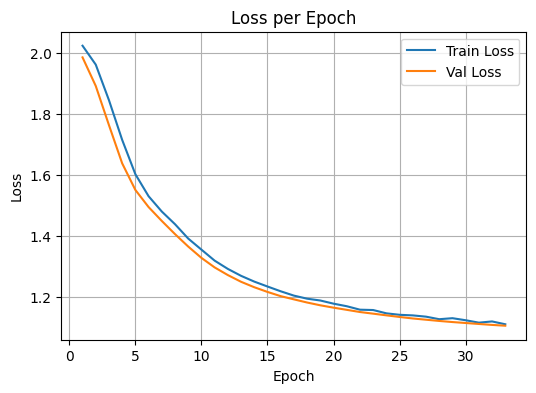

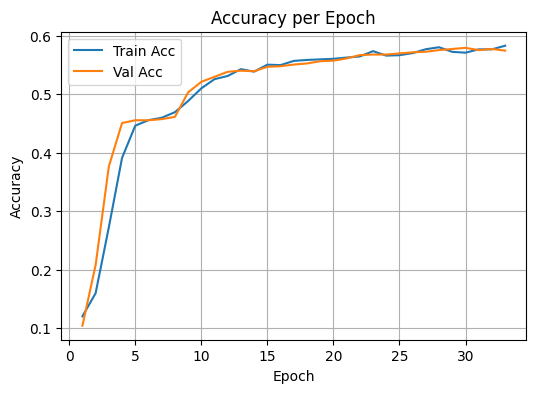

In [ ]:
plot_metrics(metrics_rubert_freeze)

Снижение лосса есть, рост метрики есть, но выход на плато случился гораздо ральше, чем хотелось. Результат обучения - 0.5796.

freeze_backbone=False

In [ ]:
rubert_tiny_transformer_model = TransformerClassificationModel(
    base_transformer_model="cointegrated/rubert-tiny2",
    n_classes=7,
    dropout=0.25
)
model_rubert_unfreezed, metrics_rubert_unfreezed = train_transformer(rubert_tiny_transformer_model, freeze_backbone=False)

/tmp/ipykernel_37/1059099080.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Epoch 1/100 [train]:   0%|          | 0/131 [00:00<?, ?it/s]/tmp/ipykernel_37/1059099080.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/100 [train]: 100%|██████████| 131/131 [00:19<00:00,  6.56it/s, acc=0.2304, loss=1.8941, lr=1.00e-06,1.00e-05]
/tmp/ipykernel_37/1059099080.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=use_amp):


[Epoch 01] train_loss=1.8941 train_acc=0.2304 val_loss=1.8105 val_acc=0.3680 lrs=['1.00e-06', '1.00e-05']


Epoch 2/100 [train]: 100%|██████████| 131/131 [00:19<00:00,  6.59it/s, acc=0.4256, loss=1.7255, lr=2.00e-06,2.00e-05]


[Epoch 02] train_loss=1.7255 train_acc=0.4256 val_loss=1.6135 val_acc=0.4557 lrs=['2.00e-06', '2.00e-05']


Epoch 3/100 [train]: 100%|██████████| 131/131 [00:19<00:00,  6.58it/s, acc=0.4571, loss=1.5608, lr=3.00e-06,3.00e-05]


...

[Epoch 16] train_loss=0.8240 train_acc=0.6808 val_loss=0.9703 val_acc=0.6149 lrs=['9.89e-06', '9.89e-05']


Epoch 17/100 [train]: 100%|██████████| 131/131 [00:19<00:00,  6.58it/s, acc=0.6885, loss=0.7959, lr=9.85e-06,9.85e-05]


[Epoch 17] train_loss=0.7959 train_acc=0.6885 val_loss=0.9751 val_acc=0.6149 lrs=['9.85e-06', '9.85e-05']


Epoch 18/100 [train]: 100%|██████████| 131/131 [00:19<00:00,  6.58it/s, acc=0.6913, loss=0.7902, lr=9.81e-06,9.81e-05]
                                                                   

[Epoch 18] train_loss=0.7902 train_acc=0.6913 val_loss=0.9795 val_acc=0.6072 lrs=['9.81e-06', '9.81e-05']
Early stopping: no improvement 3/3
Loaded best checkpoint (val_acc=0.6292 at epoch 15)


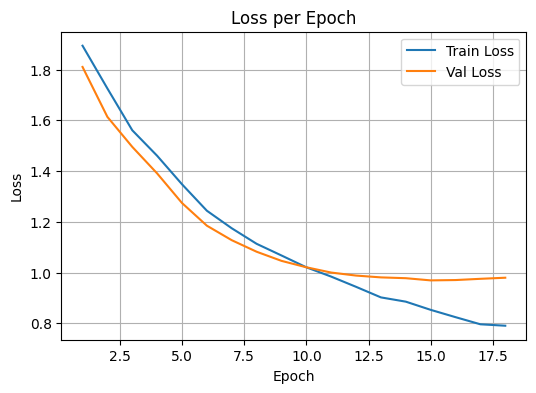

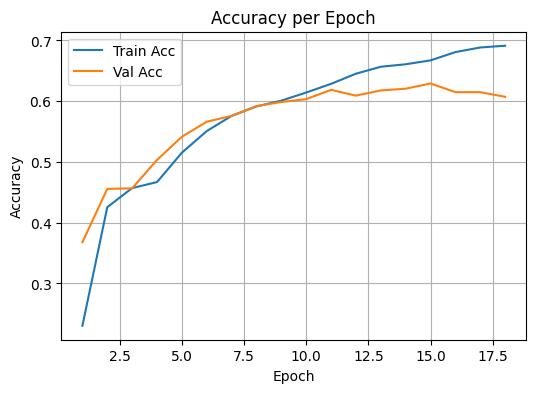

In [ ]:
plot_metrics(metrics_rubert_unfreezed)

Точность выросла до 0.6292, лосс также упал. Модель стала сильнее, но и чувствительнее к переобучению, первые признаки которого можно наблюдать после 12 эпохи.

С учетом того, что датасет мал и с выраженным дисбалансом классов, это не самый плохой результат для данной метрики.

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

freeze_backbone=True

In [ ]:
mathbert_transformer_model = TransformerClassificationModel(
    base_transformer_model='tbs17/MathBERT',
    n_classes=7,
    dropout=0.25
)

model_mathbert_freeze, metrics_mathbert_freeze = train_transformer(mathbert_transformer_model, freeze_backbone=True)

/tmp/ipykernel_37/1059099080.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Epoch 1/100 [train]:   0%|          | 0/131 [00:00<?, ?it/s]/tmp/ipykernel_37/1059099080.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/100 [train]: 100%|██████████| 131/131 [01:09<00:00,  1.88it/s, acc=0.1341, loss=2.0832, lr=1.00e-05]
/tmp/ipykernel_37/1059099080.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=use_amp):


[Epoch 01] train_loss=2.0832 train_acc=0.1341 val_loss=1.9419 val_acc=0.1792 lrs=['1.00e-05']


Epoch 2/100 [train]: 100%|██████████| 131/131 [01:10<00:00,  1.87it/s, acc=0.2631, loss=1.8759, lr=2.00e-05]


[Epoch 02] train_loss=1.8759 train_acc=0.2631 val_loss=1.6605 val_acc=0.4175 lrs=['2.00e-05']


Epoch 3/100 [train]: 100%|██████████| 131/131 [01:10<00:00,  1.87it/s, acc=0.4148, loss=1.6601, lr=3.00e-05]


...

[Epoch 19] train_loss=1.1612 train_acc=0.5604 val_loss=1.1136 val_acc=0.5577 lrs=['9.76e-05']


Epoch 20/100 [train]: 100%|██████████| 131/131 [01:10<00:00,  1.87it/s, acc=0.5720, loss=1.1419, lr=9.70e-05]


[Epoch 20] train_loss=1.1419 train_acc=0.5720 val_loss=1.1071 val_acc=0.5643 lrs=['9.70e-05']


Epoch 21/100 [train]: 100%|██████████| 131/131 [01:10<00:00,  1.87it/s, acc=0.5771, loss=1.1336, lr=9.64e-05]
                                                                   

[Epoch 21] train_loss=1.1336 train_acc=0.5771 val_loss=1.1060 val_acc=0.5558 lrs=['9.64e-05']
Early stopping: no improvement 3/3
Loaded best checkpoint (val_acc=0.5653 at epoch 18)


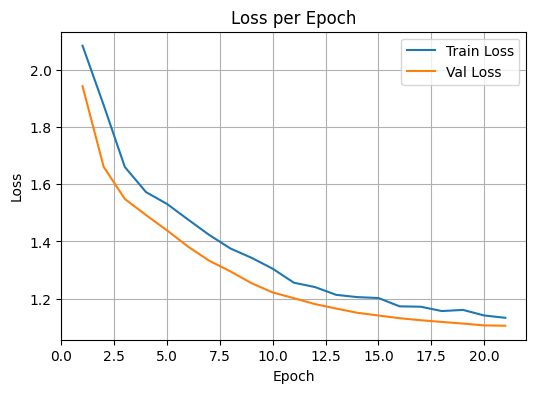

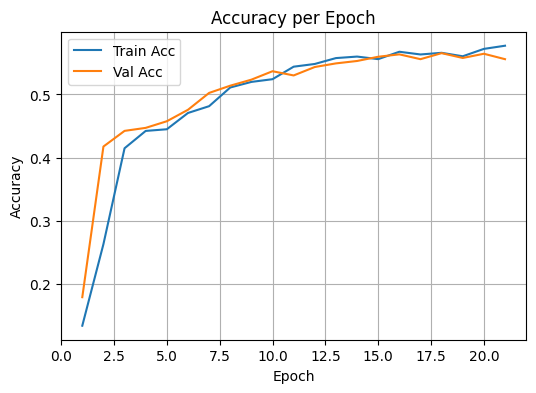

In [ ]:
plot_metrics(metrics_mathbert_freeze)

Замороженный MathBERT ведёт себя устойчиво и не переобучается: loss падает плавно, accuracy выходит на 0.565 и стабилизируется. Модель извлекла всё возможное из статичных математических эмбеддингов.

Результаты обеих замороженных моделей на лучших эпохах:

**rubert-tiny2:** train_loss=1.1244 val_loss=1.1153 val_acc = 0.5796

**MathBERT:** train_loss=1.1572 val_loss=1.1193  val_acc = 0.5653

У обеих моделей loss на валидации практически идентичен, но у MathBERT train_loss чуть выше. Также rubert-tiny2 достиг немного лучшей точности.

Несмотря на то, что MathBERT изначально предназначен для математических текстов, его преимущество не проявилось в режиме замороженного backbone. Возможно это связано с тем, что условия задач более близки к естественному языку, чем к академическим математическим трудам.

freeze_backbone=False

In [ ]:
mathbert_transformer_model = TransformerClassificationModel(
    base_transformer_model='tbs17/MathBERT',
    n_classes=7,
    dropout=0.25
)

model_mathbert_unfreezed, metrics_mathbert_unfreezed = train_transformer(mathbert_transformer_model, freeze_backbone=False)

/tmp/ipykernel_37/1059099080.py:49: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Epoch 1/100 [train]:   0%|          | 0/131 [00:00<?, ?it/s]/tmp/ipykernel_37/1059099080.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/100 [train]: 100%|██████████| 131/131 [03:24<00:00,  1.56s/it, acc=0.4089, loss=1.7088, lr=1.00e-06,1.00e-05]
/tmp/ipykernel_37/1059099080.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=use_amp):


[Epoch 01] train_loss=1.7088 train_acc=0.4089 val_loss=1.5116 val_acc=0.4633 lrs=['1.00e-06', '1.00e-05']


Epoch 2/100 [train]: 100%|██████████| 131/131 [03:24<00:00,  1.56s/it, acc=0.4668, loss=1.4799, lr=2.00e-06,2.00e-05]


[Epoch 02] train_loss=1.4799 train_acc=0.4668 val_loss=1.2993 val_acc=0.5234 lrs=['2.00e-06', '2.00e-05']


Epoch 3/100 [train]: 100%|██████████| 131/131 [03:24<00:00,  1.56s/it, acc=0.5491, loss=1.2493, lr=3.00e-06,3.00e-05]


...

[Epoch 06] train_loss=0.9130 train_acc=0.6555 val_loss=0.9877 val_acc=0.5786 lrs=['6.00e-06', '6.00e-05']


Epoch 7/100 [train]: 100%|██████████| 131/131 [03:24<00:00,  1.56s/it, acc=0.6708, loss=0.8373, lr=7.00e-06,7.00e-05]


[Epoch 07] train_loss=0.8373 train_acc=0.6708 val_loss=0.9994 val_acc=0.5891 lrs=['7.00e-06', '7.00e-05']


Epoch 8/100 [train]: 100%|██████████| 131/131 [03:25<00:00,  1.57s/it, acc=0.7052, loss=0.7459, lr=8.00e-06,8.00e-05]
                                                                  

[Epoch 08] train_loss=0.7459 train_acc=0.7052 val_loss=1.0300 val_acc=0.5748 lrs=['8.00e-06', '8.00e-05']
Early stopping: no improvement 3/3
Loaded best checkpoint (val_acc=0.6034 at epoch 5)


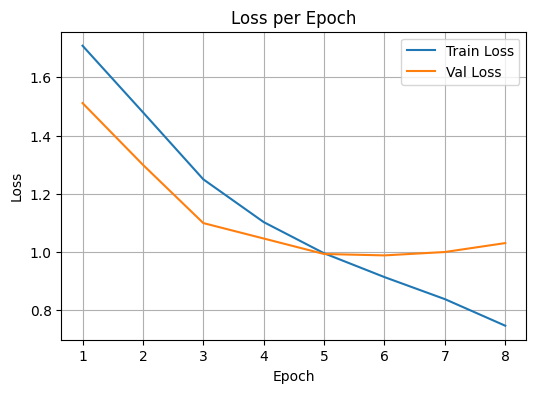

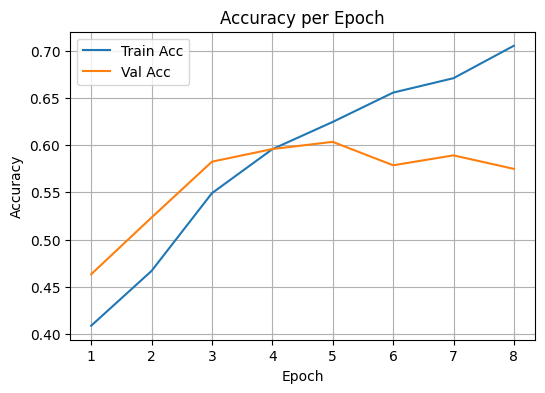

In [ ]:
plot_metrics(metrics_mathbert_unfreezed)

Наблюдается улучшение по сравнению с замороженным режимом: валидационная точность увеличилась с 0.5653 до 0.6034.
До 5 эпохи - стремительный рост train и val accuracy. После 5 эпохи - train_acc продолжает расти (до 0.7052), а val_acc проседает. Это первый явный признак переобучения после оптимума.

Оба лосса падают до 5 эпохи. С 6 эпохи train_loss продолжает снижаться, а val_loss растет, и это подтверждает начало переобучения.

Это типично для fine-tuning на малом датасете.

Результаты обеих моделей после разморозки backbone на их лучших эпохах:

**rubert-tiny2:** train_loss=0.8528 val_loss=0.9689 val_acc=0.6292

**MathBERT:** train_loss=0.9950 val_loss=0.9225 val_acc=0.6034

Разморозка существенно повысила качество обеих моделей (4–5 к accuracy относительно freeze). Обе показывают заметное улучшение качества классификации и уверенное снижение loss.

Rubert-tiny2 достиг наилучшего результата по точности (0.6292), демонстрируя способность обобщать на англоязычных текстах математических задач.

Разница между моделями статистически несущественна, поэтому обе можно рассматривать как неплохие решения.

MathBERT уступает по метрике, и возможно это связано с тем, что его крупная и специализированная архитектура не получает достаточного количества обобщающих способностей. На 4 000 примеров он склонен запоминать тренировочные тексты и не улучшать валидацию.

Для маленького датасета tiny-модель обучается проще: меньше параметров, меньше переобучения, быстрее адаптация.
MathBERT-base требует как минимум в 5–10 раз больше данных, чтобы fine-tuning был устойчивым.

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from transformers import AutoTokenizer

def plot_first_layer_attention_for_df_row(
    model,
    tokenizer,
    row_idx: int,
    n_cols: int = 12
):

    row = df.iloc[row_idx]
    text = str(row['problem_text'])

    model = model.to(device)
    model.eval()

    with torch.no_grad():
        enc = tokenizer(text, return_tensors="pt", padding=False, truncation=True)
        enc = {k: v.to(device) for k, v in enc.items()}
        feed = {k: enc[k] for k in ("input_ids", "attention_mask") if k in enc}
        if "token_type_ids" in enc:
            feed["token_type_ids"] = enc["token_type_ids"]

        out = model.backbone(**feed, output_attentions=True)
        attn = out.attentions[0][0]

        tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist(), skip_special_tokens=False)

    H, T, _ = attn.shape
    n_rows = math.ceil(H / n_cols)
    fig = plt.figure(figsize=(3.2 * n_cols, 3.2 * n_rows))
    for i in range(H):
        ax = fig.add_subplot(n_rows, n_cols, i + 1)
        a = attn[i].detach().cpu().numpy()
        im = ax.imshow(a, cmap="bone", aspect="auto")
        ax.set_title(f"Head {i}", fontsize=9)
        ax.set_xticks(range(T)); ax.set_yticks(range(T))
        ax.set_xticklabels(tokens, rotation=90, fontsize=7)
        ax.set_yticklabels(tokens, fontsize=7)
        ax.xaxis.set_major_formatter(ticker.FixedFormatter(tokens))
        ax.yaxis.set_major_formatter(ticker.FixedFormatter(tokens))
    fig.tight_layout()
    return fig


### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

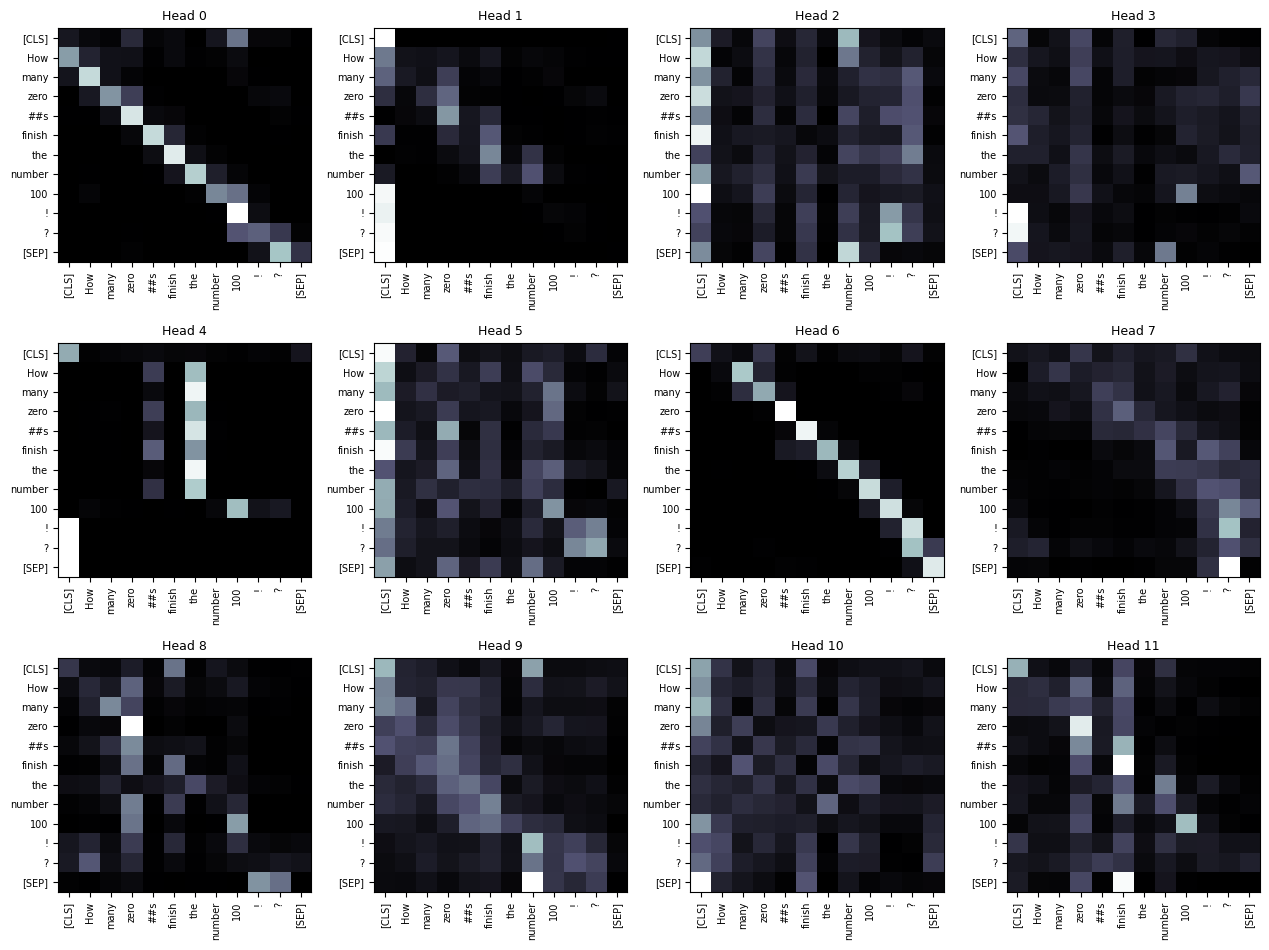

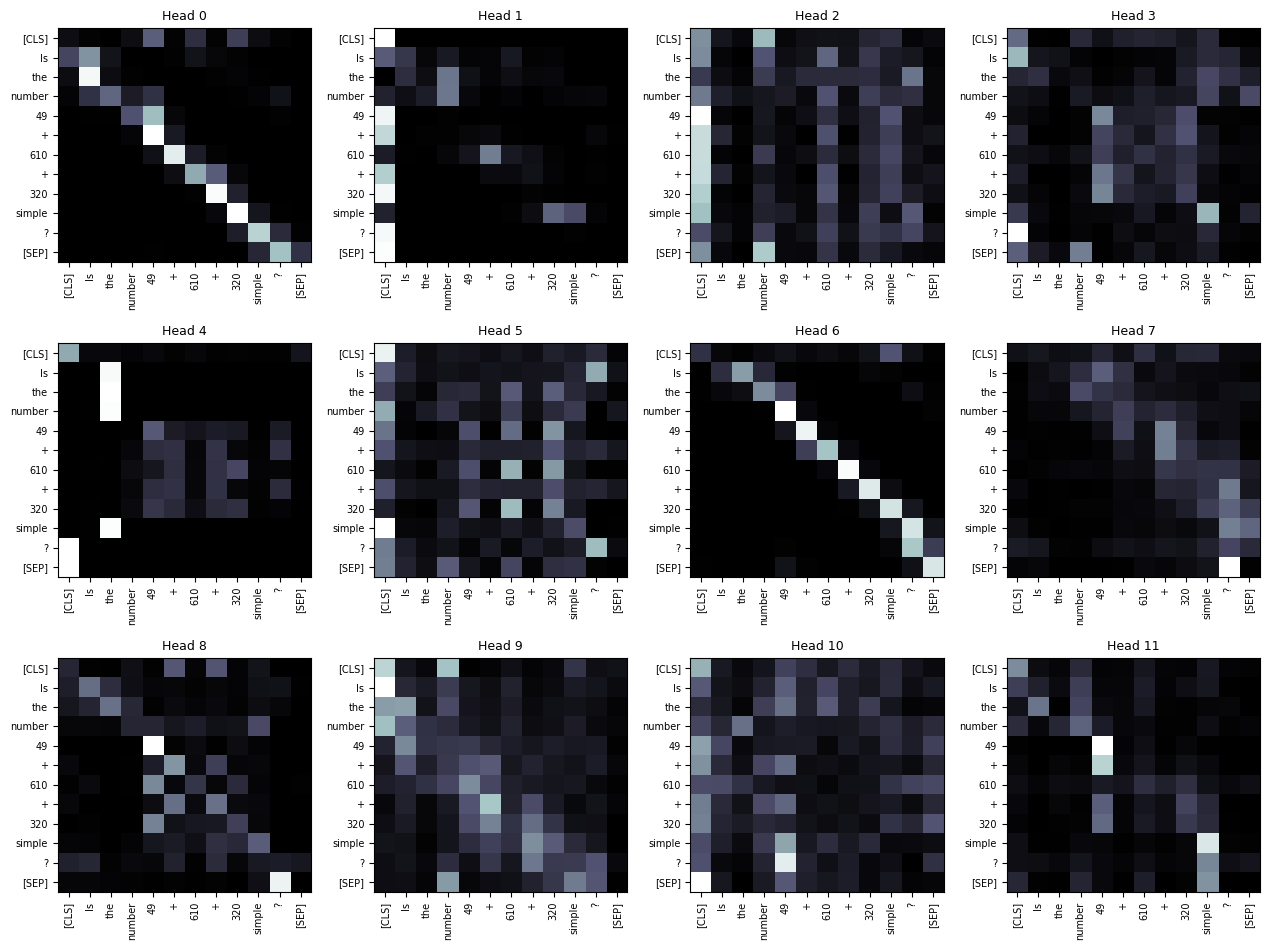

In [ ]:
untrained_rubert = TransformerClassificationModel(
    base_transformer_model="cointegrated/rubert-tiny2",
    n_classes=7,
    dropout=0.25)
rubert_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

untrained_rubert = untrained_rubert.to(device)

fig1 = plot_first_layer_attention_for_df_row(untrained_rubert, rubert_tokenizer,row_idx=2943, n_cols = 4)
fig2 = plot_first_layer_attention_for_df_row(untrained_rubert, rubert_tokenizer,row_idx=2384, n_cols = 4)
plt.show()


**Строки — откуда внимание идёт, столбцы — куда оно направлено.
Яркое пятно = высокий вес внимания.**

Рассмотрим два предложения.

"How many zeros finish the number 100!?"
"Is the number 49+610+320 simple?"

Head 0 и 6 - почти чистая диагональ: токен смотрит на себя и соседей. Видимо, удерживает порядок слов.

Head 2 - почти все строки смотрят на [CLS]. Слабая вертикаль около “finish”, "zero", "number", и квадратик возле "?" и "!" в первом предложении, и вертикали около "number", "610", "320", "simple" во втором. Возможно, это говорит о выделении глобального контекста и границ предложения.

Head 4 акцентирует внимание всех словестных токенов на "the", то есть работает как грамматическая опора: показывает модели, где начинается объект.

Head 5 и 11 явно обращают внимание на числа.


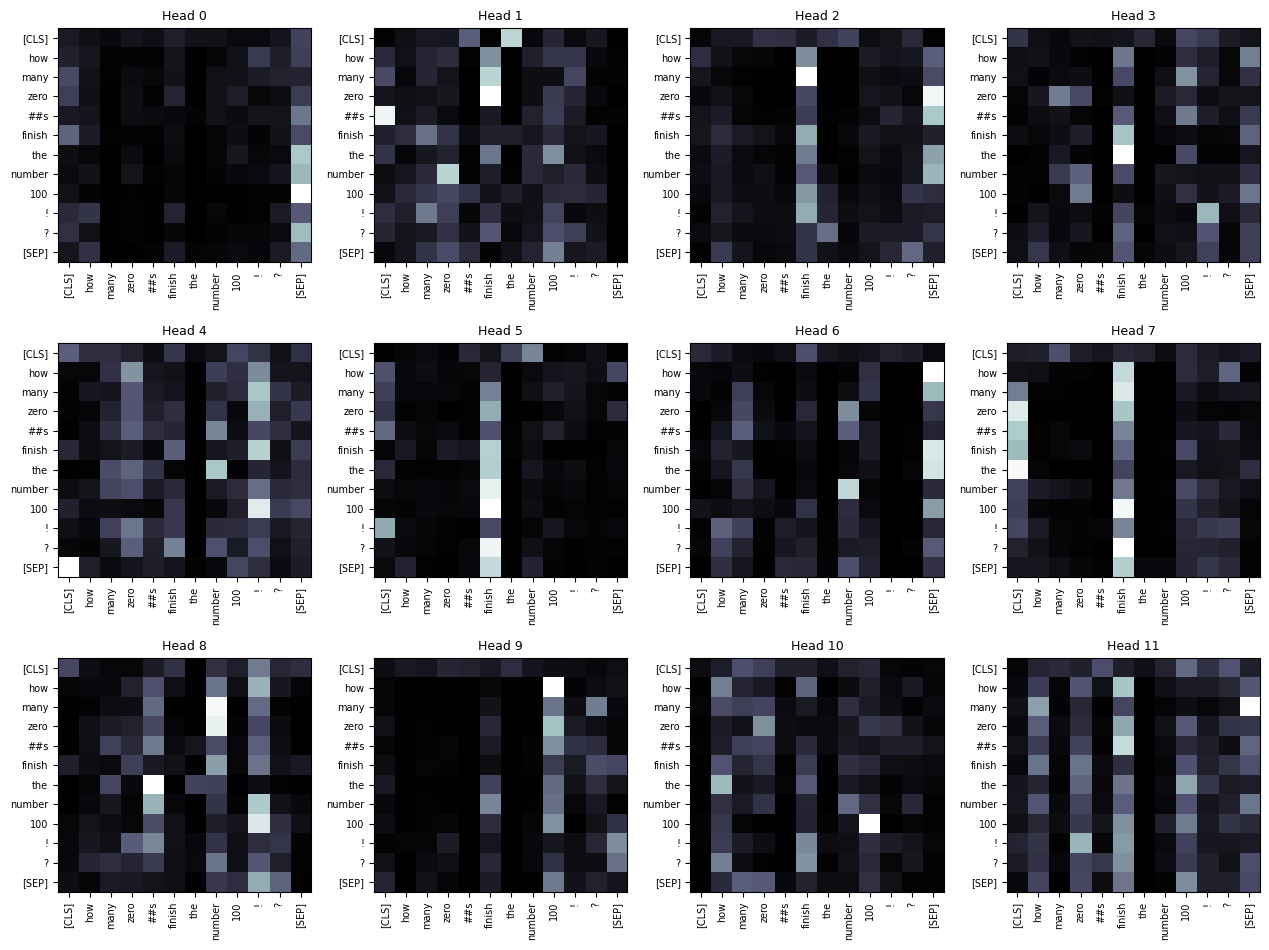

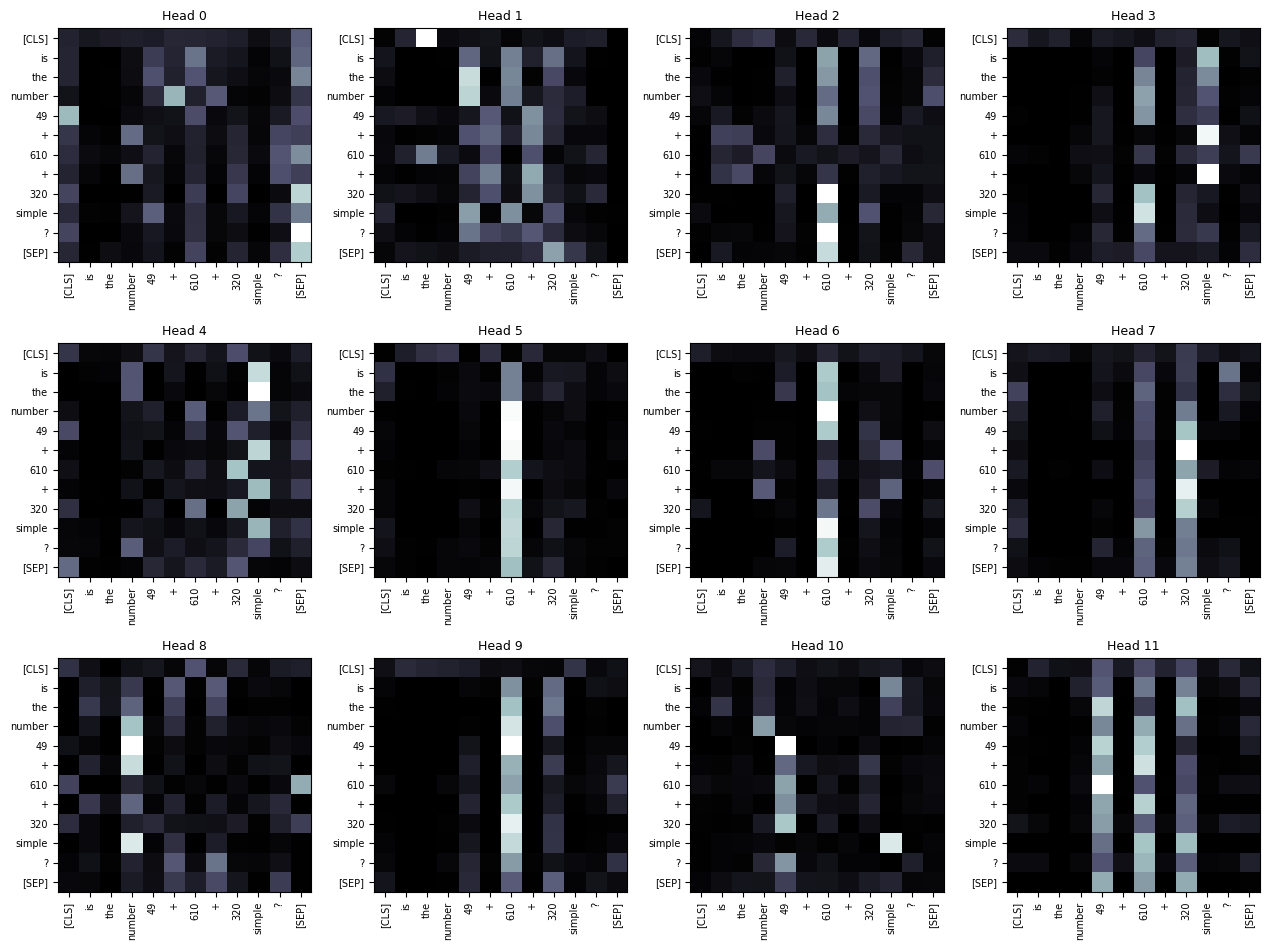

In [ ]:
untrained_mathbert = TransformerClassificationModel(
    base_transformer_model='tbs17/MathBERT',
    n_classes=7,
    dropout=0.25)
mathbert_tokenizer = AutoTokenizer.from_pretrained('tbs17/MathBERT')

untrained_mathbert = untrained_mathbert.to(device)

fig1 = plot_first_layer_attention_for_df_row(untrained_mathbert, mathbert_tokenizer, row_idx=2943, n_cols = 4)
fig2 = plot_first_layer_attention_for_df_row(untrained_mathbert, mathbert_tokenizer, row_idx=2384, n_cols = 4)
plt.show()

Заметим, что диагоналей тут нет. И это интересно.

Head 1, если приглядеться, выделяет главные смысловые слова в задачах. "many zero finish the number" и "the number simple"

Heads 2 и 3 - вертикали на “finish”, "simple" и числах.

Head 5. Яркая полоса на "finish" и "610" - центральных словах предложений.

Head 9. Яркая полоса на "100" и "610".

Head 4	Смешанный паттерн: внимание к "!" и "simple" - последним словам в предложении. Возможно, обозначает грамматическую структуру.

Head 11	Точечные акценты на всем, что связано с числами.

Модель уже дообучена на текстах с числами, поэтому считает их информационными ядрами, в то время как rubert-tiny2 видит предложение как грамматическую последовательность.

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

Для более детального просмотра - клик на картинку

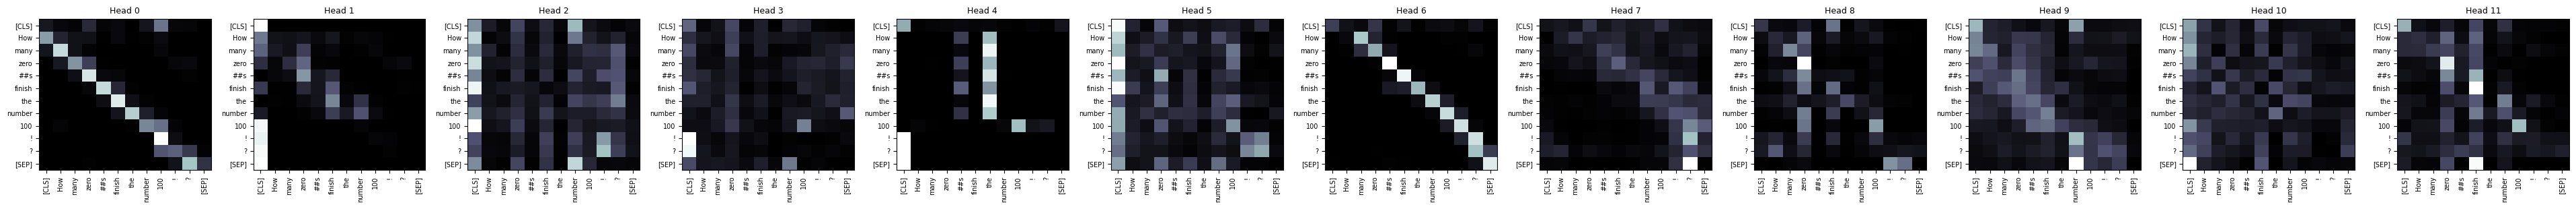

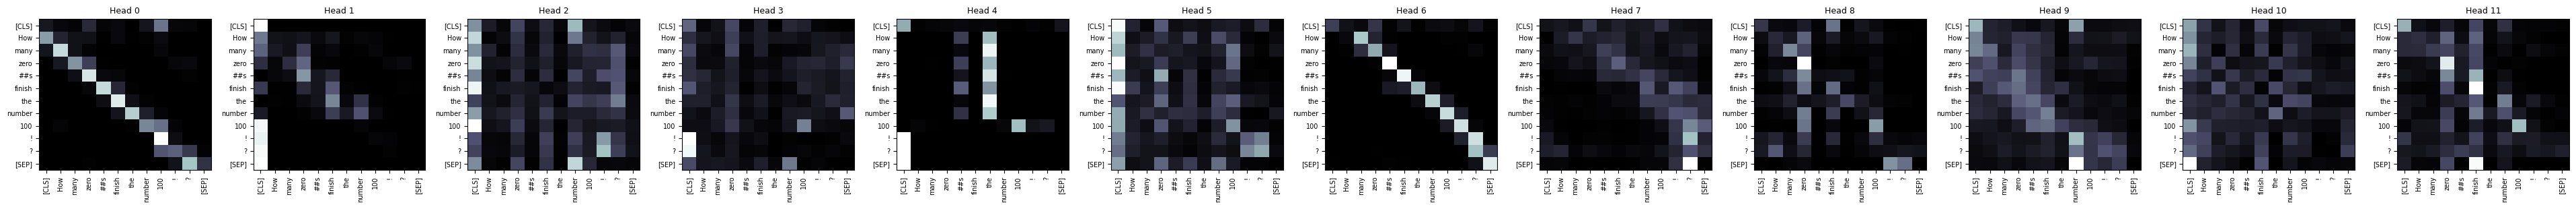

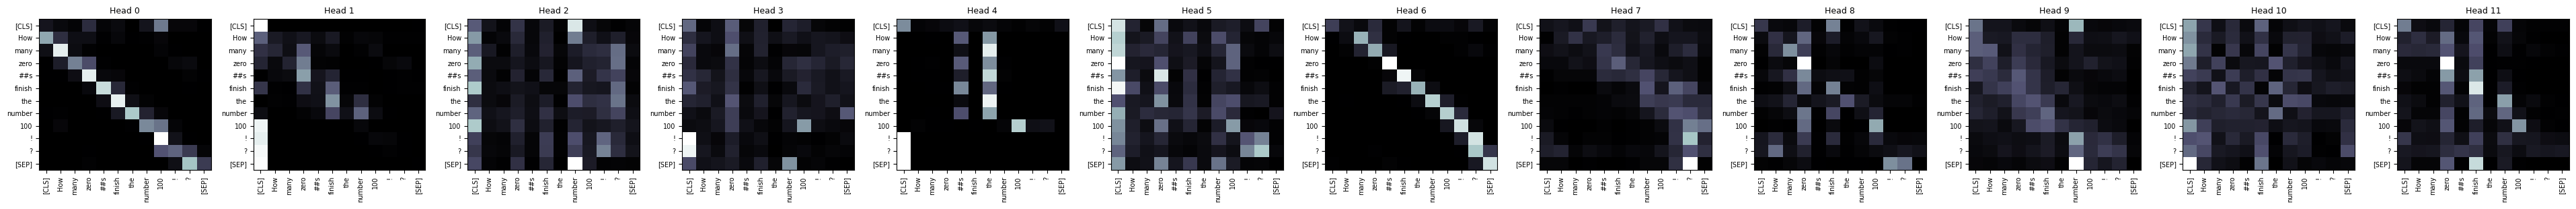

In [ ]:
fig0 = plot_first_layer_attention_for_df_row(untrained_rubert, rubert_tokenizer,row_idx=2943)
fig1 = plot_first_layer_attention_for_df_row(model_rubert_freeze, rubert_tokenizer,row_idx=2943)
fig2 = plot_first_layer_attention_for_df_row(model_rubert_unfreezed, rubert_tokenizer,row_idx=2943)
plt.show()

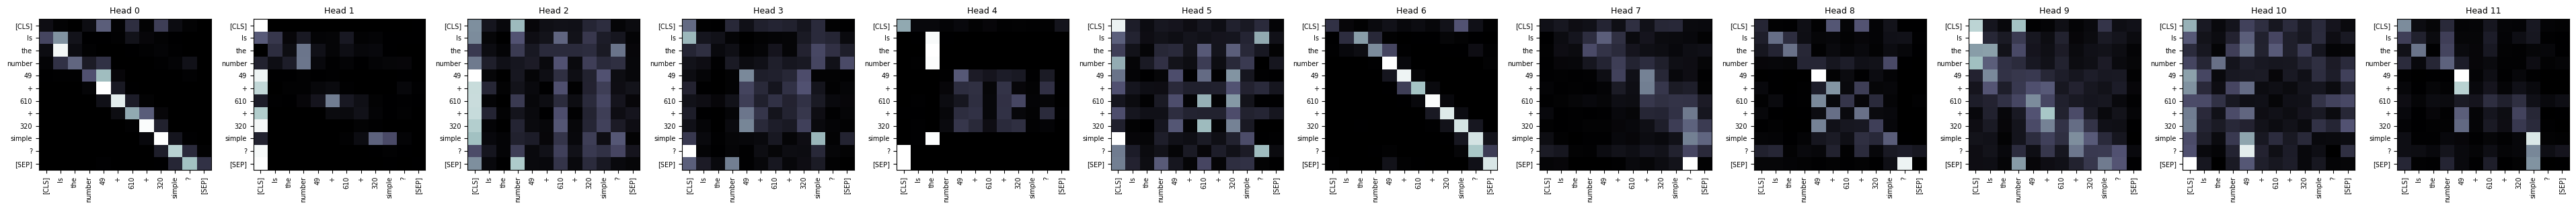

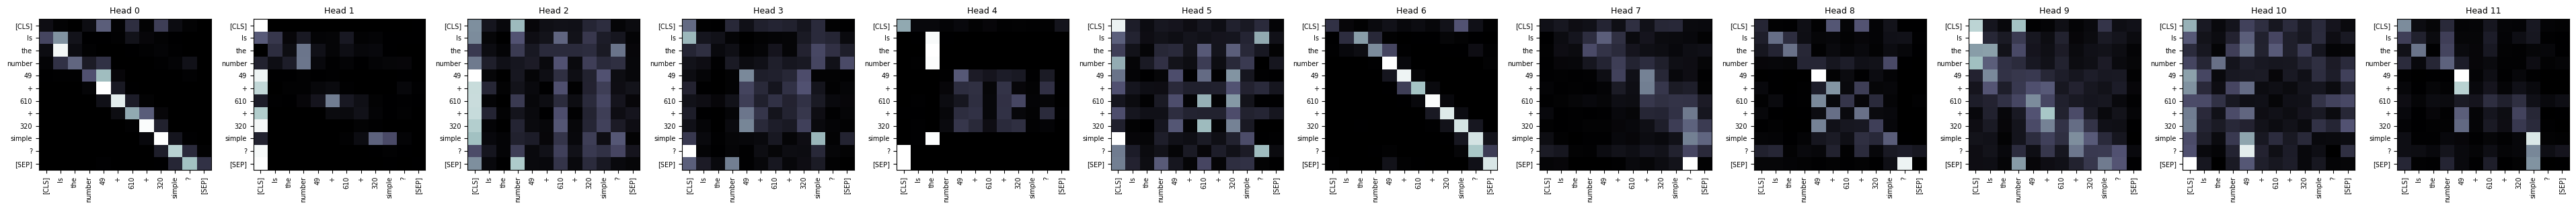

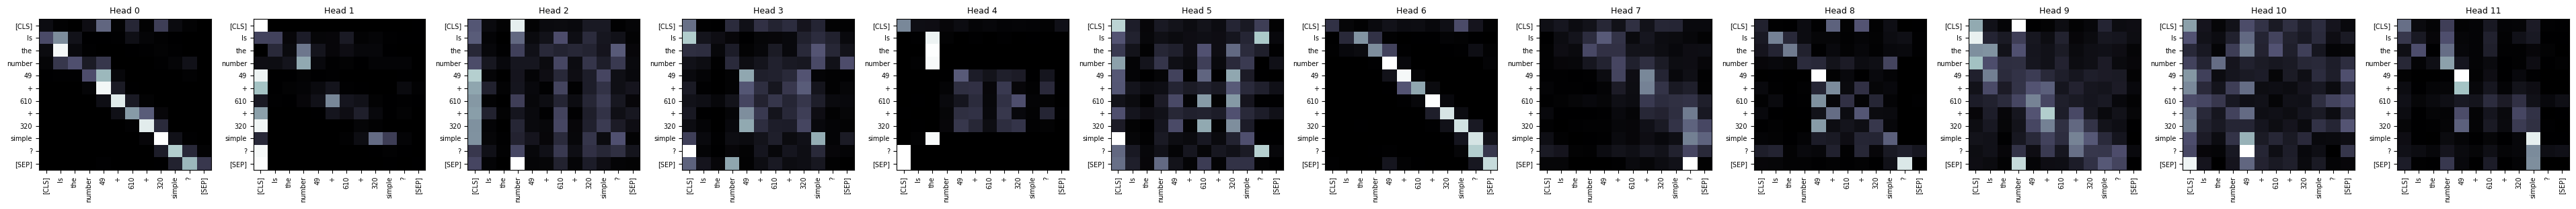

In [ ]:
fig0 = plot_first_layer_attention_for_df_row(untrained_rubert, rubert_tokenizer,row_idx=2384)
fig1 = plot_first_layer_attention_for_df_row(model_rubert_freeze, rubert_tokenizer,row_idx=2384)
fig2 = plot_first_layer_attention_for_df_row(model_rubert_unfreezed, rubert_tokenizer,row_idx=2384)
plt.show()

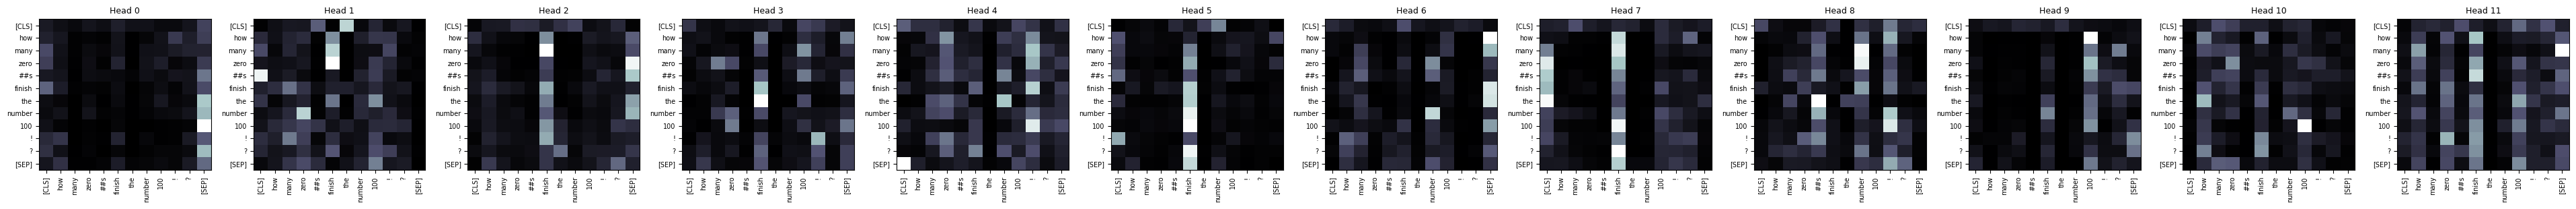

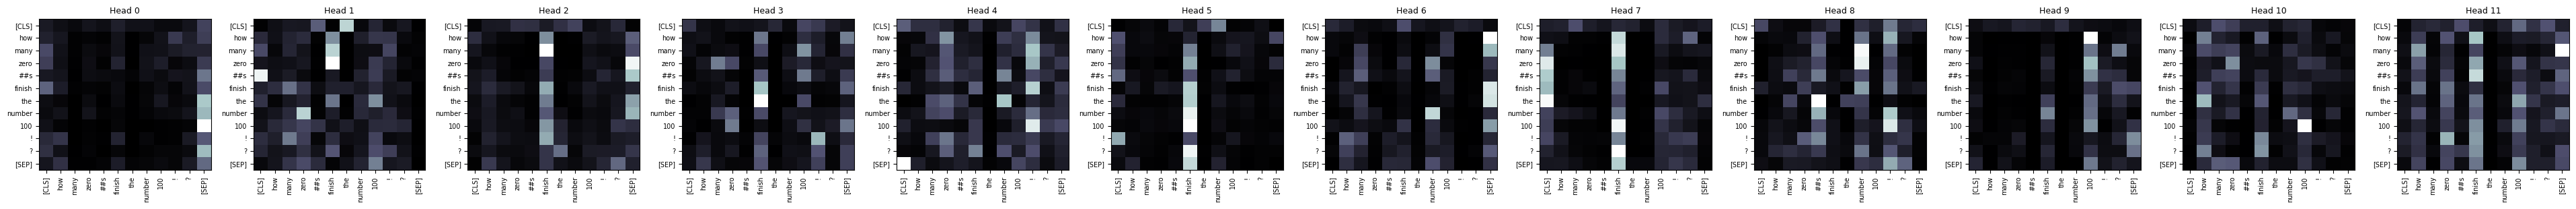

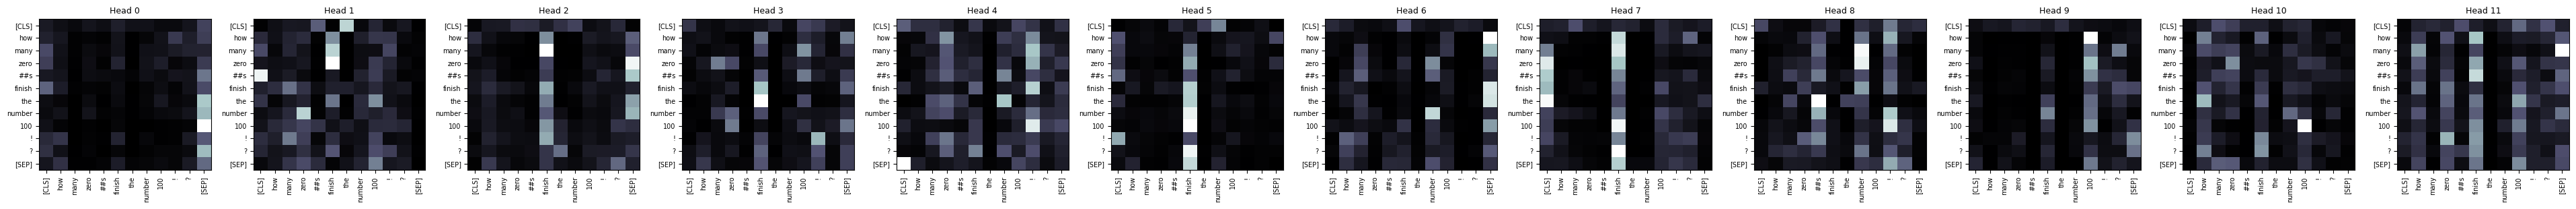

In [ ]:
fig0 = plot_first_layer_attention_for_df_row(untrained_mathbert, mathbert_tokenizer, row_idx=2943)
fig1 = plot_first_layer_attention_for_df_row(model_mathbert_freeze, mathbert_tokenizer,row_idx=2943)
fig2 = plot_first_layer_attention_for_df_row(model_mathbert_freeze, mathbert_tokenizer,row_idx=2943)
plt.show()

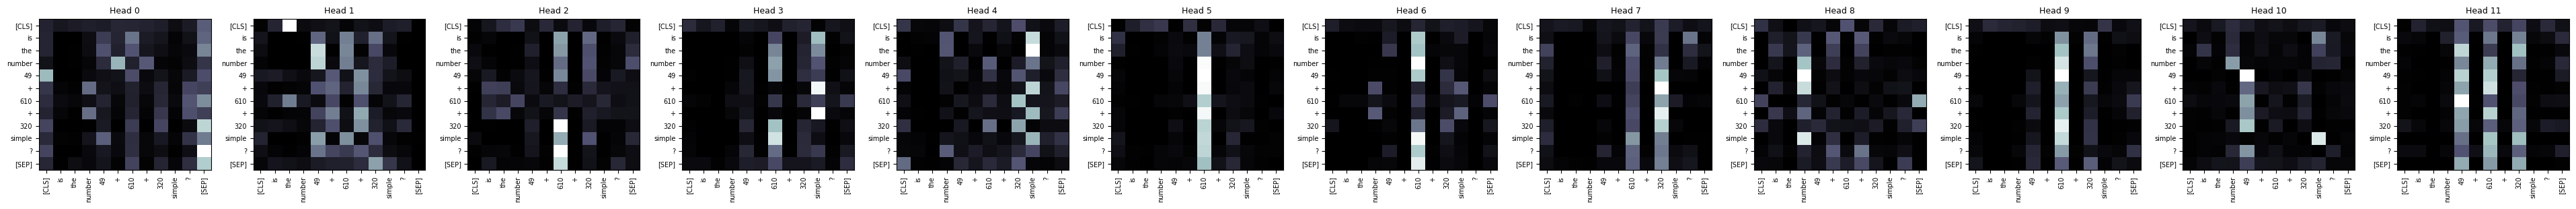

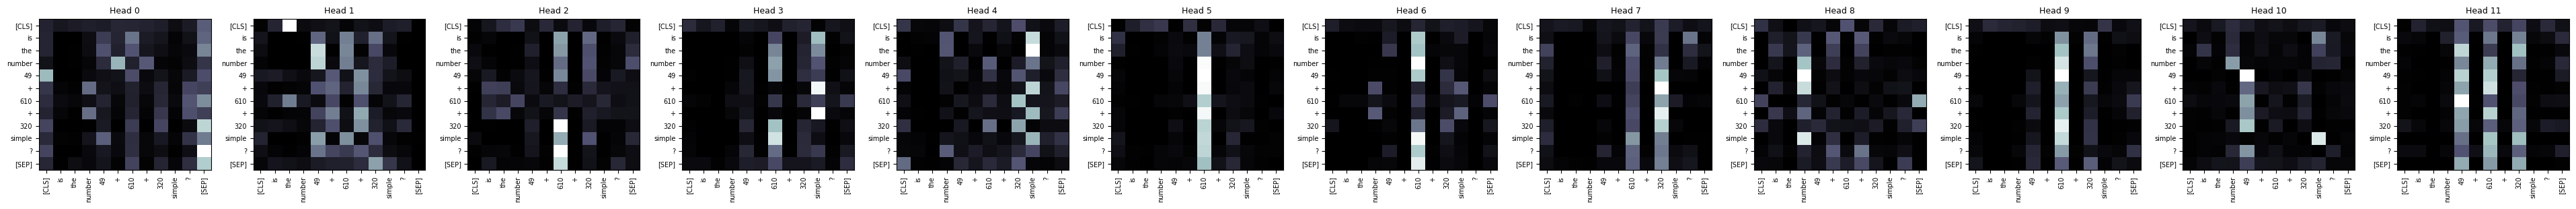

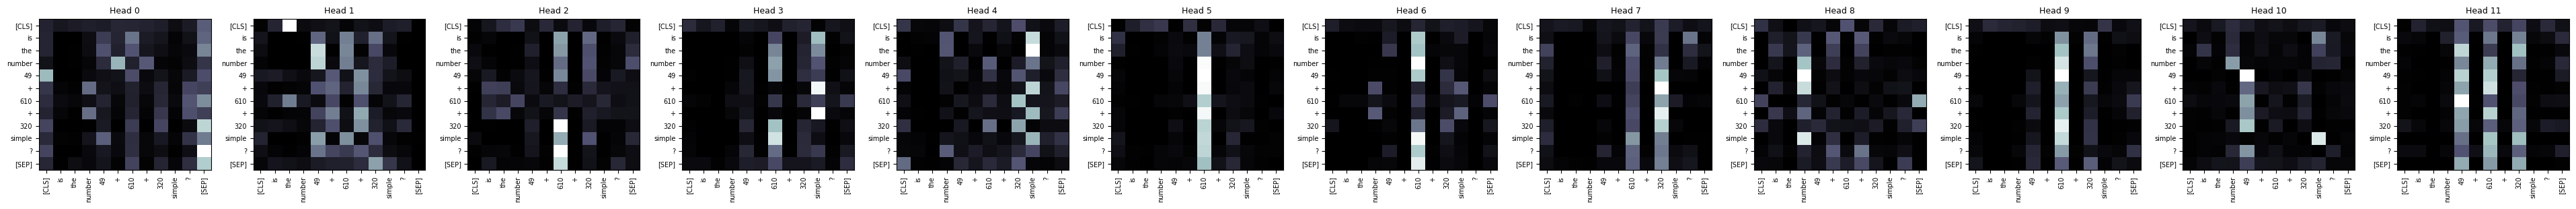

In [ ]:
fig0 = plot_first_layer_attention_for_df_row(untrained_mathbert, mathbert_tokenizer, row_idx=2384)
fig1 = plot_first_layer_attention_for_df_row(model_mathbert_freeze, mathbert_tokenizer,row_idx=2384)
fig2 = plot_first_layer_attention_for_df_row(model_mathbert_freeze, mathbert_tokenizer,row_idx=2384)
plt.show()

Сразу можно признать очевидное - большой разницы в картах внимания нет, паттерны остаются примерно теми же. Но, если хорошо приглядеться, можно заметить увеличение и уменьшение яркости некоторых отдельных точек.

Это можно объяснить тем, что при заморозке fine-tuning учит только линейный слой, а attention-карты остаются неизменными.
А также тем, что первый слой внимания выучивает синтаксис, позиционные закономерности и морфологию и почти не перестраивается при дообучении на задаче классификации.